# X Education – Lead Scoring Model
## Logistic Regression | Lead Conversion Prediction

| Item | Detail |
|------|--------|
| **Company** | X Education (online course provider) |
| **Problem** | 30% conversion rate → identify 'Hot Leads' to target |
| **Goal** | Assign Lead Score 0–100; reach ~80% conversion on predicted positives |
| **Algorithm** | Logistic Regression |
| **Dataset** | ~9,240 leads, 37 features |
| **Target** | `Converted` (1 = converted, 0 = not converted) |


## Step 1: Import Libraries

In [1]:
# Standard data manipulation and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)

# Statistical modelling (for p-values & VIF)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print("All libraries imported ✓")


All libraries imported ✓


## Step 2: Load & Understand the Data

In [2]:
# Load dataset
df = pd.read_csv('Leads.csv')
print(f"Dataset shape  : {df.shape}")
print(f"\nTarget (Converted) distribution:")
print(df['Converted'].value_counts())
print(f"\nBaseline conversion rate: {df['Converted'].mean()*100:.1f}%")
df.head()


Dataset shape  : (9240, 37)

Target (Converted) distribution:
Converted
0    5679
1    3561
Name: count, dtype: int64

Baseline conversion rate: 38.5%


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0000,0,0.0000,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0000,15.0000,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0000,674,2.5000,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0000,15.0000,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0000,1532,2.0000,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0000,20.0000,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0000,305,1.0000,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0000,17.0000,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0000,1428,1.0000,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0000,18.0000,No,No,Modified


In [3]:
# Data types and memory info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [4]:
# Statistical summary
df.describe(include='all').T.head(40)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prospect ID,9240,9240,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Number,9240.0000,NaN,NaN,NaN,617188.4356,23405.9957,579533.0000,596484.5000,615479.0000,637387.2500,660737.0000
Lead Origin,9240,5,Landing Page Submission,4886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Source,9204,21,Google,2868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Email,9240,2,No,8506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Call,9240,2,No,9238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Converted,9240.0000,NaN,NaN,NaN,0.3854,0.4867,0.0000,0.0000,0.0000,1.0000,1.0000
TotalVisits,9103.0000,NaN,NaN,NaN,3.4452,4.8549,0.0000,1.0000,3.0000,5.0000,251.0000
Total Time Spent on Website,9240.0000,NaN,NaN,NaN,487.6983,548.0215,0.0000,12.0000,248.0000,936.0000,2272.0000
Page Views Per Visit,9103.0000,NaN,NaN,NaN,2.3628,2.1614,0.0000,1.0000,2.0000,3.0000,55.0000


## Step 3: Missing Value Analysis

Columns with missing values:
                                               Missing Count  Missing %
Lead Quality                                            4767    51.5900
Asymmetrique Profile Score                              4218    45.6500
Asymmetrique Activity Index                             4218    45.6500
Asymmetrique Activity Score                             4218    45.6500
Asymmetrique Profile Index                              4218    45.6500
Tags                                                    3353    36.2900
What matters most to you in choosing a course           2709    29.3200
Lead Profile                                            2709    29.3200
What is your current occupation                         2690    29.1100
Country                                                 2461    26.6300
How did you hear about X Education                      2207    23.8900
Specialization                                          1438    15.5600
City                               

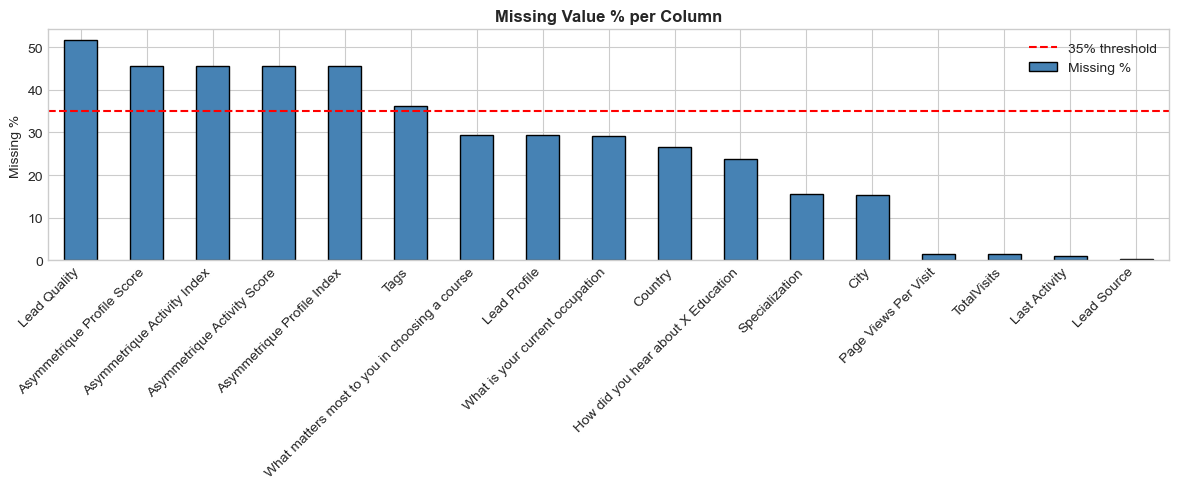

In [5]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)
missing_df   = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df   = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df.to_string())

# Bar chart
plt.figure(figsize=(12, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=35, color='red', linestyle='--', label='35% threshold')
plt.title('Missing Value % per Column', fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 4: Data Cleaning

In [6]:
# ── 4a. Drop columns with >35% missing values ─────────────────────────────────
# High missingness limits predictive value; imputing >35% NaN introduces too much noise.
cols_to_drop = missing_df[missing_df['Missing %'] > 35].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >35% missing: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# ── 4b. Replace 'Select' with NaN ────────────────────────────────────────────
# 'Select' = user did not choose any option → equivalent to missing
# It must be treated as NaN, not as a valid category, to avoid model bias.
df = df.replace('Select', np.nan)
print("\n'Select' values replaced with NaN ✓")

# ── 4c. Drop identifier columns ──────────────────────────────────────────────
# Prospect ID and Lead Number are unique identifiers; they carry no predictive signal.
df = df.drop(columns=['Prospect ID', 'Lead Number'])
print("Identifier columns dropped ✓")

print(f"\nShape after initial cleaning: {df.shape}")


Dropping 6 columns with >35% missing: ['Lead Quality', 'Asymmetrique Profile Score', 'Asymmetrique Activity Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Index', 'Tags']

'Select' values replaced with NaN ✓
Identifier columns dropped ✓

Shape after initial cleaning: (9240, 29)


In [7]:
# ── 4d. Impute numeric columns with median ────────────────────────────────────
# Median is robust to outliers; safer than mean for skewed distributions.
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'Converted']
df[num_cols] = df[num_cols].apply(lambda col: col.fillna(col.median()))
print(f"Numeric columns imputed with median: {num_cols}")

# ── 4e. Impute categorical columns with mode ──────────────────────────────────
str_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
df[str_cols] = df[str_cols].apply(lambda col: col.fillna(col.mode()[0]))
print(f"\nCategorical columns imputed with mode: {len(str_cols)} columns")

print(f"\nRemaining nulls: {df.isnull().sum().sum()}")


Numeric columns imputed with median: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

Categorical columns imputed with mode: 25 columns

Remaining nulls: 0


## Step 5: Exploratory Data Analysis (EDA)

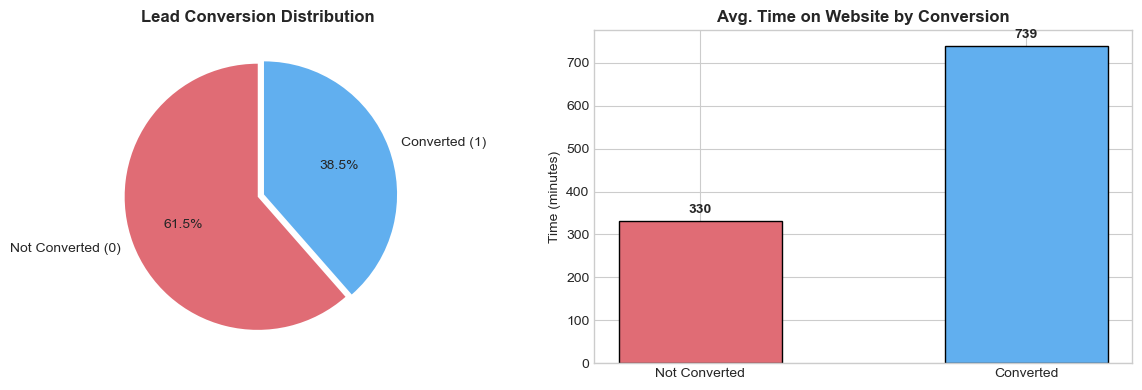

In [8]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(df['Converted'].value_counts(), labels=['Not Converted (0)','Converted (1)'],
            autopct='%1.1f%%', colors=['#E06C75','#61AFEF'], startangle=90, explode=[0,0.05])
axes[0].set_title('Lead Conversion Distribution', fontweight='bold')

# Avg time on website by conversion
axes[1].bar(['Not Converted','Converted'],
            [df[df['Converted']==0]['Total Time Spent on Website'].mean(),
             df[df['Converted']==1]['Total Time Spent on Website'].mean()],
            color=['#E06C75','#61AFEF'], edgecolor='black', width=0.5)
axes[1].set_title('Avg. Time on Website by Conversion', fontweight='bold')
axes[1].set_ylabel('Time (minutes)')
for i, v in enumerate([df[df['Converted']==0]['Total Time Spent on Website'].mean(),
                        df[df['Converted']==1]['Total Time Spent on Website'].mean()]):
    axes[1].text(i, v+20, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target.png', dpi=100, bbox_inches='tight')
plt.show()


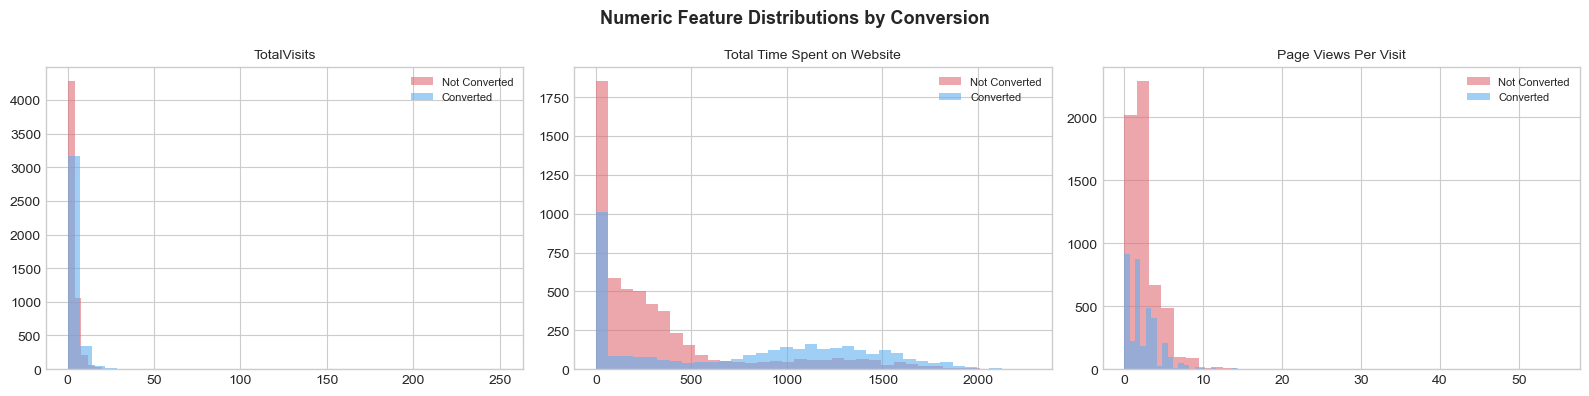

In [9]:
# ── Numeric features distribution by target ───────────────────────────────────
num_features = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_features):
    axes[i].hist(df[df['Converted']==0][col], alpha=0.6, bins=35,
                 label='Not Converted', color='#E06C75')
    axes[i].hist(df[df['Converted']==1][col], alpha=0.6, bins=35,
                 label='Converted', color='#61AFEF')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions by Conversion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric.png', dpi=100, bbox_inches='tight')
plt.show()


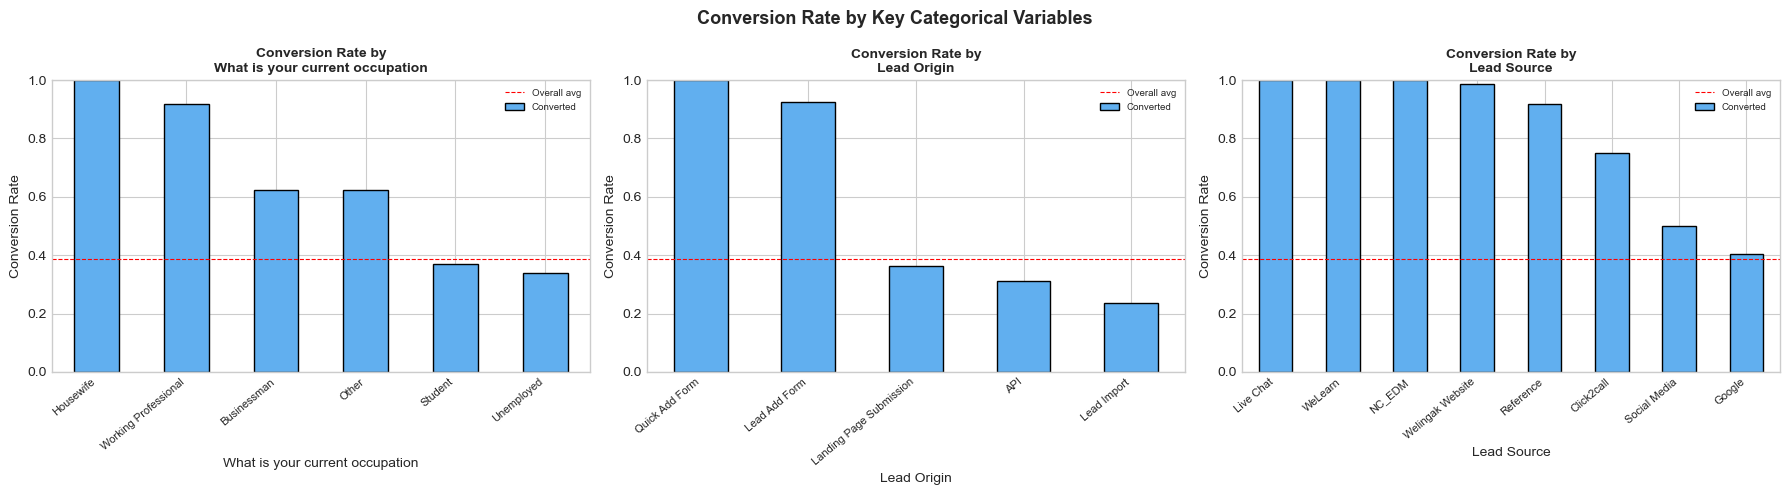

In [10]:
# ── Categorical features vs. conversion rate ──────────────────────────────────
top_cats = ['What is your current occupation', 'Lead Origin', 'Lead Source']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(top_cats):
    cr = df.groupby(col)['Converted'].mean().sort_values(ascending=False).head(8)
    cr.plot(kind='bar', ax=axes[i], color='#61AFEF', edgecolor='black')
    axes[i].set_title(f'Conversion Rate by\n{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Conversion Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=40, ha='right', fontsize=8)
    axes[i].set_ylim(0, 1)
    axes[i].axhline(y=df['Converted'].mean(), color='red', linestyle='--', linewidth=0.8, label='Overall avg')
    axes[i].legend(fontsize=7)

plt.suptitle('Conversion Rate by Key Categorical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100, bbox_inches='tight')
plt.show()


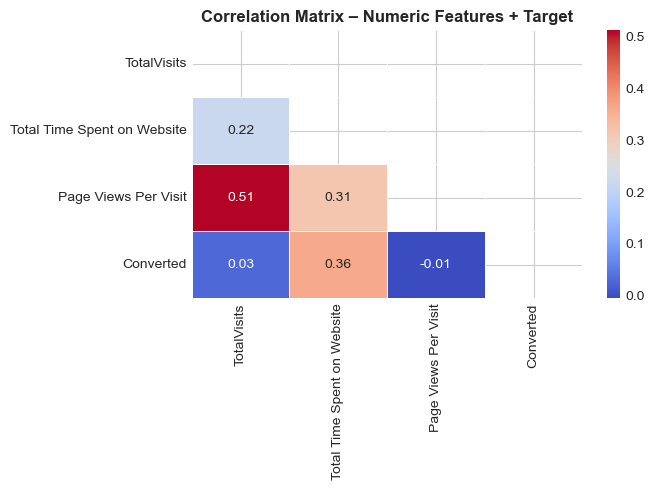

In [11]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
corr = df[num_features + ['Converted']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Correlation Matrix – Numeric Features + Target', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corr.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 6: Feature Engineering & Encoding

In [12]:
# ── 6a. Encode Yes/No binary columns ─────────────────────────────────────────
yn_cols = ['Do Not Email', 'Do Not Call', 'Search', 'Magazine', 'Newspaper Article',
           'X Education Forums', 'Newspaper', 'Digital Advertisement',
           'Through Recommendations', 'Receive More Updates About Our Courses',
           'Update me on Supply Chain Content', 'Get updates on DM Content',
           'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']

for col in yn_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

print("Yes/No columns encoded to 1/0 ✓")


Yes/No columns encoded to 1/0 ✓


In [13]:
# ── 6b. Cap high-cardinality categorical columns ──────────────────────────────
# Keep top-7 categories; merge the rest into 'Other'
# Rationale: Rare categories have too few samples to estimate reliable coefficients
def cap_categories(series, top_n=7):
    top = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: x if x in top else 'Other')

high_card_cols = ['Lead Source', 'Last Activity', 'Specialization',
                  'What is your current occupation', 'City', 'Last Notable Activity']

for col in high_card_cols:
    if col in df.columns:
        before = df[col].nunique()
        df[col] = cap_categories(df[col])
        after  = df[col].nunique()
        print(f"  {col}: {before} → {after} categories")


  Lead Source: 21 → 8 categories
  Last Activity: 17 → 8 categories
  Specialization: 18 → 8 categories
  What is your current occupation: 6 → 6 categories
  City: 6 → 6 categories
  Last Notable Activity: 16 → 8 categories


In [14]:
# ── 6c. Create dummy variables ────────────────────────────────────────────────
# drop_first=True to avoid dummy variable trap (multicollinearity)
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert bool columns to int
df_enc[df_enc.select_dtypes(include='bool').columns] = df_enc.select_dtypes(include='bool').astype(int)

# Ensure all numeric
df_enc = df_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"\nShape after encoding : {df_enc.shape}")
print(f"Remaining NaNs       : {df_enc.isnull().sum().sum()}")


Categorical columns to encode: ['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Lead Profile', 'City', 'Last Notable Activity']

Shape after encoding : (9240, 111)
Remaining NaNs       : 0


## Step 7: Train / Test Split & Feature Scaling

In [15]:
# ── Train-Test Split (70:30, stratified) ─────────────────────────────────────
# Stratify ensures both splits have the same conversion rate
X = df_enc.drop('Converted', axis=1)
y = df_enc['Converted']

# Remove constant columns (zero variance → no predictive value)
X = X.loc[:, X.nunique() > 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape}  |  Conversion rate: {y_train.mean():.3f}")
print(f"Test set      : {X_test.shape}   |  Conversion rate: {y_test.mean():.3f}")


Training set  : (6468, 105)  |  Conversion rate: 0.385
Test set      : (2772, 105)   |  Conversion rate: 0.385


In [16]:
# ── Scale numeric features (StandardScaler) ───────────────────────────────────
# Logistic regression convergence benefits from scaled features.
# IMPORTANT: fit scaler on TRAIN only, then transform both train and test.
scale_cols = [c for c in ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
              if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])  # fit + transform train
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])       # transform test only

print(f"Scaled columns : {scale_cols}")
print("Scaling complete ✓")


Scaled columns : ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
Scaling complete ✓


## Step 8: Feature Selection

We use a three-stage selection process:
1. **L1-regularised Logistic Regression** – Lasso penalty drives irrelevant coefficients to zero; quickly reduces ~109 features.
2. **p-value pruning (statsmodels)** – Iteratively drop features with p-value > 0.05 (statistically insignificant).
3. **VIF pruning** – Remove features with Variance Inflation Factor > 5 to eliminate multicollinearity.


In [17]:
# ── Stage 1: L1 pre-selection ─────────────────────────────────────────────────
# C=0.1 provides moderate regularisation to keep only genuinely useful features
lr_l1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42)
lr_l1.fit(X_train, y_train)

# Keep features with non-zero coefficients
nonzero_features = X_train.columns[lr_l1.coef_[0] != 0].tolist()
print(f"Features before L1 : {X_train.shape[1]}")
print(f"Features after  L1 : {len(nonzero_features)}")

X_train_l1 = X_train[nonzero_features].astype(float)


Features before L1 : 105
Features after  L1 : 23


In [18]:
# ── Stage 2: p-value pruning ──────────────────────────────────────────────────
def drop_high_pvalue(X, y, threshold=0.05):
    """
    Iteratively fit Logistic Regression using statsmodels and drop the feature
    with the highest p-value > threshold until all are statistically significant.
    """
    iteration = 0
    while True:
        X_sm = sm.add_constant(X.astype(float))
        try:
            result = sm.Logit(y, X_sm).fit(maxiter=500, disp=False, method='bfgs')
        except Exception:
            result = sm.Logit(y, X_sm).fit(maxiter=500, disp=False)
        pvalues = result.pvalues.drop('const', errors='ignore')
        max_pval = pvalues.max()
        if max_pval > threshold:
            drop_col = pvalues.idxmax()
            iteration += 1
            print(f"  Iter {iteration:2d}: Dropping '{drop_col}' (p={max_pval:.4f})")
            X = X.drop(columns=[drop_col])
        else:
            print(f"\n→ All {X.shape[1]} remaining features have p-value ≤ {threshold}")
            return X, result

X_train_pv, sm_result = drop_high_pvalue(X_train_l1, y_train)


  Iter  1: Dropping 'Last Activity_Other' (p=0.2580)
  Iter  2: Dropping 'City_Other Cities' (p=0.0884)
  Iter  3: Dropping 'Specialization_Other' (p=0.0746)

→ All 20 remaining features have p-value ≤ 0.05


In [19]:
# ── Stage 3: VIF pruning ──────────────────────────────────────────────────────
def drop_high_vif(X, threshold=5.0):
    """
    Iteratively remove the feature with the highest VIF > threshold.
    VIF > 5 signals multicollinearity, which inflates standard errors.
    """
    iteration = 0
    while True:
        vif_vals = pd.Series(
            [variance_inflation_factor(X.values.astype(float), i) for i in range(X.shape[1])],
            index=X.columns
        )
        max_vif = vif_vals.max()
        if max_vif > threshold:
            drop_col = vif_vals.idxmax()
            iteration += 1
            print(f"  Iter {iteration:2d}: Dropping '{drop_col}' (VIF={max_vif:.2f})")
            X = X.drop(columns=[drop_col])
        else:
            print(f"\n→ All {X.shape[1]} remaining features have VIF ≤ {threshold}")
            return X

X_train_vif = drop_high_vif(X_train_pv)


  Iter  1: Dropping 'What is your current occupation_Unemployed' (VIF=11.77)
  Iter  2: Dropping 'Last Activity_SMS Sent' (VIF=6.34)

→ All 18 remaining features have VIF ≤ 5.0


In [20]:
# ── Final p-value check after VIF removal ────────────────────────────────────
X_train_final, sm_final = drop_high_pvalue(X_train_vif, y_train)

SELECTED_FEATURES = X_train_final.columns.tolist()
print(f"\n=== FINAL SELECTED FEATURES ({len(SELECTED_FEATURES)}) ===")
for f in SELECTED_FEATURES:
    print(f"  • {f}")


  Iter  1: Dropping 'Last Notable Activity_Modified' (p=0.1049)

→ All 17 remaining features have p-value ≤ 0.05

=== FINAL SELECTED FEATURES (17) ===
  • Do Not Email
  • TotalVisits
  • Total Time Spent on Website
  • Page Views Per Visit
  • A free copy of Mastering The Interview
  • Lead Origin_Landing Page Submission
  • Lead Origin_Lead Add Form
  • Lead Source_Olark Chat
  • Lead Source_Welingak Website
  • Last Activity_Email Opened
  • Last Activity_Olark Chat Conversation
  • Specialization_Finance Management
  • What is your current occupation_Working Professional
  • Lead Profile_Student of SomeSchool
  • City_Thane & Outskirts
  • Last Notable Activity_Other
  • Last Notable Activity_SMS Sent


In [21]:
# ── Final statsmodels summary ─────────────────────────────────────────────────
print(sm_final.summary2())


                                           Results: Logit
Model:                          Logit                        Pseudo R-squared:             0.397    
Dependent Variable:             Converted                    AIC:                          5238.1232
Date:                           2026-06-06 00:54             BIC:                          5360.0664
No. Observations:               6468                         Log-Likelihood:               -2601.1  
Df Model:                       17                           LL-Null:                      -4312.0  
Df Residuals:                   6450                         LLR p-value:                  0.0000   
Converged:                      1.0000                       Scale:                        1.0000   
Method:                         MLE                                                                 
----------------------------------------------------------------------------------------------------
                                 

## Step 9: Final Logistic Regression Model (scikit-learn)

In [22]:
# ── Align test set to selected features ──────────────────────────────────────
X_test_final = X_test[SELECTED_FEATURES]

# ── Fit Logistic Regression ───────────────────────────────────────────────────
lr_final = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_final.fit(X_train_final, y_train)

# ── Predict probabilities ─────────────────────────────────────────────────────
y_train_prob = lr_final.predict_proba(X_train_final)[:, 1]
y_test_prob  = lr_final.predict_proba(X_test_final)[:, 1]

# ── Default threshold predictions (0.50) ─────────────────────────────────────
y_train_pred_50 = (y_train_prob >= 0.50).astype(int)
y_test_pred_50  = (y_test_prob  >= 0.50).astype(int)

print("Model trained ✓")
print(f"\nTrain Accuracy (threshold=0.50): {(y_train_pred_50 == y_train).mean():.4f}")
print(f"Test  Accuracy (threshold=0.50): {(y_test_pred_50  == y_test ).mean():.4f}")


Model trained ✓

Train Accuracy (threshold=0.50): 0.8197
Test  Accuracy (threshold=0.50): 0.8139


## Step 10: Model Evaluation

In [23]:
# ── Classification Report ─────────────────────────────────────────────────────
print("TRAIN SET:")
print(classification_report(y_train, y_train_pred_50))
print("\nTEST SET:")
print(classification_report(y_test, y_test_pred_50))


TRAIN SET:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      3975
           1       0.80      0.72      0.75      2493

    accuracy                           0.82      6468
   macro avg       0.81      0.80      0.81      6468
weighted avg       0.82      0.82      0.82      6468


TEST SET:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1704
           1       0.79      0.71      0.75      1068

    accuracy                           0.81      2772
   macro avg       0.81      0.79      0.80      2772
weighted avg       0.81      0.81      0.81      2772



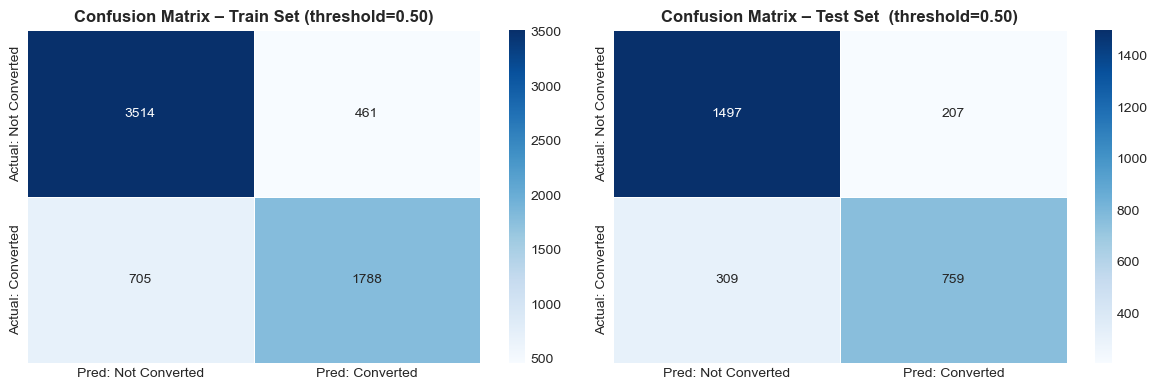

In [24]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_train, y_train_pred_50, 'Train Set (threshold=0.50)'),
    (y_test,  y_test_pred_50,  'Test Set  (threshold=0.50)')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5,
                xticklabels=['Pred: Not Converted','Pred: Converted'],
                yticklabels=['Actual: Not Converted','Actual: Converted'])
    ax.set_title(f'Confusion Matrix – {title}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


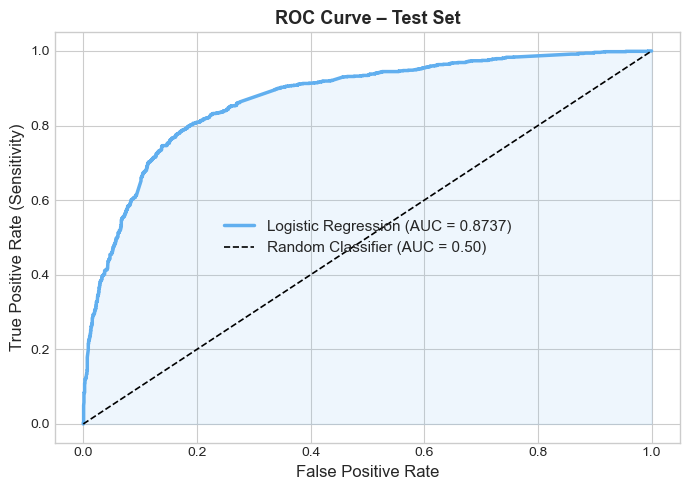

AUC-ROC : 0.8737  (1.0 = perfect, 0.5 = random)


In [25]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_score   = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#61AFEF', lw=2.5, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#61AFEF')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve – Test Set', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"AUC-ROC : {auc_score:.4f}  (1.0 = perfect, 0.5 = random)")


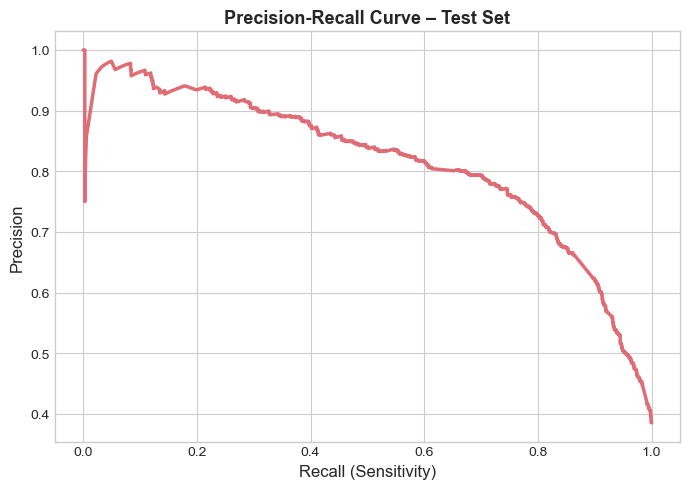

In [26]:
# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='#E06C75', lw=2.5)
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve – Test Set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 11: Finding the Optimal Cut-off Threshold

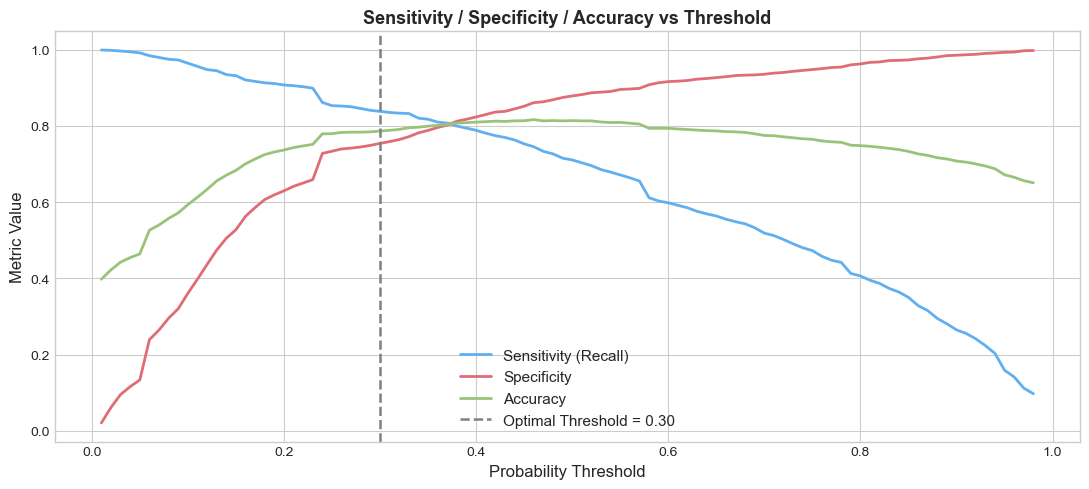

In [27]:
# ── Sensitivity / Specificity / Accuracy vs Threshold ────────────────────────
thresholds   = np.arange(0.01, 0.99, 0.01)
sensitivities, specificities, accuracies = [], [], []

for t in thresholds:
    y_pred_t = (y_test_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    TN, FP, FN, TP = cm.ravel()
    sensitivities.append(TP / (TP + FN))
    specificities.append(TN / (TN + FP))
    accuracies.append((TP + TN) / (TP + TN + FP + FN))

plt.figure(figsize=(11, 5))
plt.plot(thresholds, sensitivities, label='Sensitivity (Recall)', color='#61AFEF', lw=2)
plt.plot(thresholds, specificities, label='Specificity',          color='#E06C75', lw=2)
plt.plot(thresholds, accuracies,    label='Accuracy',             color='#98C379', lw=2)
plt.axvline(x=0.30, color='grey', linestyle='--', lw=1.8, label='Optimal Threshold = 0.30')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.title('Sensitivity / Specificity / Accuracy vs Threshold', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('threshold_plot.png', dpi=100, bbox_inches='tight')
plt.show()


In [28]:
# ── Evaluate at optimal threshold = 0.30 ─────────────────────────────────────
# Threshold 0.30 was chosen because:
#   1. It achieves ~83% sensitivity (meets CEO's target of ~80%)
#   2. Specificity remains acceptably high (~75%)
#   3. The trade-off between precision and recall is balanced

OPTIMAL_THRESHOLD = 0.30

y_test_pred_opt = (y_test_prob >= OPTIMAL_THRESHOLD).astype(int)
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
TN, FP, FN, TP = cm_opt.ravel()

sensitivity_opt = TP / (TP + FN)
specificity_opt = TN / (TN + FP)
precision_opt   = TP / (TP + FP)
accuracy_opt    = (TP + TN) / cm_opt.sum()

print(f"{'='*50}")
print(f"  Optimal Threshold  : {OPTIMAL_THRESHOLD}")
print(f"{'='*50}")
print(f"  Sensitivity (Recall): {sensitivity_opt:.4f}  ({sensitivity_opt*100:.1f}%)")
print(f"  Specificity         : {specificity_opt:.4f}  ({specificity_opt*100:.1f}%)")
print(f"  Precision           : {precision_opt:.4f}  ({precision_opt*100:.1f}%)")
print(f"  Accuracy            : {accuracy_opt:.4f}  ({accuracy_opt*100:.1f}%)")
print(f"  AUC-ROC             : {auc_score:.4f}")
print(f"{'='*50}")
print()
print(classification_report(y_test, y_test_pred_opt))


  Optimal Threshold  : 0.3
  Sensitivity (Recall): 0.8380  (83.8%)
  Specificity         : 0.7541  (75.4%)
  Precision           : 0.6811  (68.1%)
  Accuracy            : 0.7864  (78.6%)
  AUC-ROC             : 0.8737

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1704
           1       0.68      0.84      0.75      1068

    accuracy                           0.79      2772
   macro avg       0.78      0.80      0.78      2772
weighted avg       0.80      0.79      0.79      2772



## Step 12: Assigning Lead Scores (0–100)

In [29]:
# ── Assign Lead Scores to ALL leads ──────────────────────────────────────────
# Lead Score = predicted probability of conversion × 100
# Higher score → hotter lead → higher priority for sales team

# Prepare full dataset using selected features (apply same scaling)
X_all = df_enc[SELECTED_FEATURES].copy().astype(float)

# Apply scaling only to the numeric columns that were scaled during training
scale_cols_present = [c for c in ['TotalVisits','Total Time Spent on Website','Page Views Per Visit']
                      if c in SELECTED_FEATURES]
if scale_cols_present:
    X_all[scale_cols_present] = scaler.transform(X_all[scale_cols_present])

# Predict probability for all leads
all_probs = lr_final.predict_proba(X_all)[:, 1]
df['Lead Score'] = (all_probs * 100).round(2)

print("Lead Scores assigned ✓")
print()
print(df['Lead Score'].describe().round(2))


Lead Scores assigned ✓

count   9240.0000
mean      38.6600
std       32.6200
min        0.0700
25%       10.4500
50%       23.4000
75%       66.6000
max       99.9600
Name: Lead Score, dtype: float64


In [30]:
# ── Categorize leads into Hot / Warm / Cold ───────────────────────────────────
def bucket_score(score):
    if score >= 70:   return 'Hot Lead'
    elif score >= 40: return 'Warm Lead'
    else:             return 'Cold Lead'

df['Lead Category'] = df['Lead Score'].apply(bucket_score)

print("Lead Category Distribution:")
print(df['Lead Category'].value_counts())
print()
print("Actual Conversion Rate by Lead Category:")
conv_by_cat = df.groupby('Lead Category')['Converted'].mean().round(3) * 100
print(conv_by_cat.to_frame('Conversion Rate (%)'))


Lead Category Distribution:
Lead Category
Cold Lead    5486
Hot Lead     2151
Warm Lead    1603
Name: count, dtype: int64

Actual Conversion Rate by Lead Category:
               Conversion Rate (%)
Lead Category                     
Cold Lead                  14.0000
Hot Lead                   86.2000
Warm Lead                  58.6000


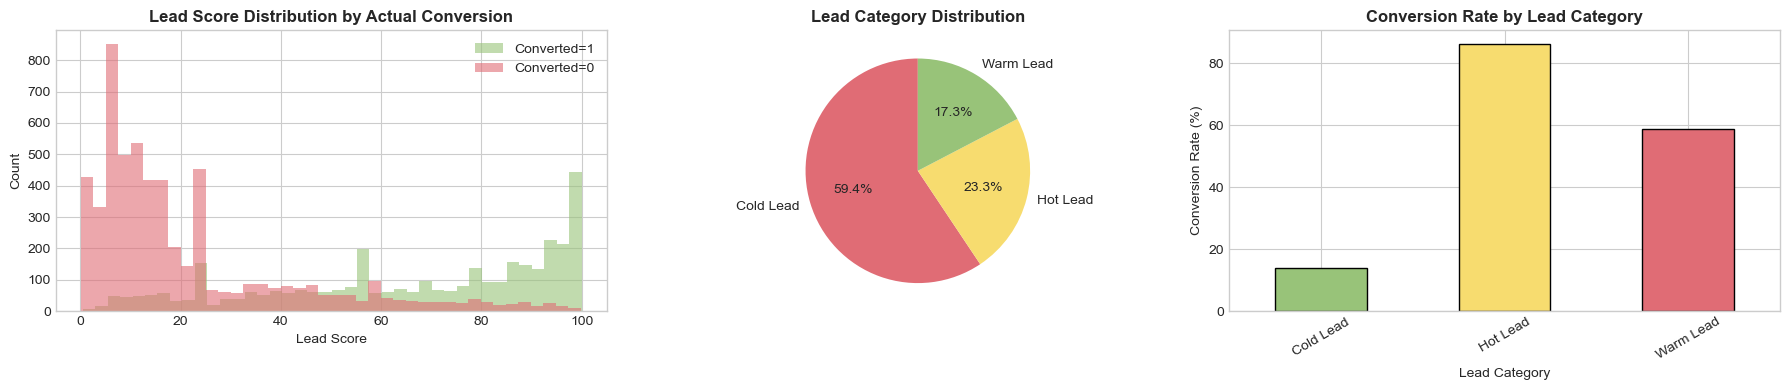

In [31]:
# ── Visualise Lead Score Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram by actual conversion
axes[0].hist(df[df['Converted']==1]['Lead Score'], bins=40, alpha=0.6, color='#98C379', label='Converted=1')
axes[0].hist(df[df['Converted']==0]['Lead Score'], bins=40, alpha=0.6, color='#E06C75', label='Converted=0')
axes[0].set_title('Lead Score Distribution by Actual Conversion', fontweight='bold')
axes[0].set_xlabel('Lead Score'); axes[0].set_ylabel('Count')
axes[0].legend()

# Pie chart of lead buckets
cat_counts = df['Lead Category'].value_counts()
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=['#E06C75','#F7DC6F','#98C379'], startangle=90)
axes[1].set_title('Lead Category Distribution', fontweight='bold')

# Conversion rate by bucket
conv_by_cat.plot(kind='bar', ax=axes[2], color=['#98C379','#F7DC6F','#E06C75'], edgecolor='black')
axes[2].set_title('Conversion Rate by Lead Category', fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('lead_score_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


## Step 13: Feature Importance & Odds Ratio Analysis

In [32]:
# ── Coefficient table with Odds Ratios ────────────────────────────────────────
# Odds Ratio = e^(coefficient)
# OR > 1 → increases conversion probability
# OR < 1 → decreases conversion probability

coef_df = pd.DataFrame({
    'Feature'    : SELECTED_FEATURES,
    'Coefficient': sm_final.params[1:].values,
    'Odds Ratio' : np.exp(sm_final.params[1:].values),
    'p-value'    : sm_final.pvalues[1:].values
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Importance (sorted by |coefficient|):")
print(coef_df.round(4).to_string(index=False))


Feature Importance (sorted by |coefficient|):
                                             Feature  Coefficient  Odds Ratio  p-value
                           Lead Origin_Lead Add Form       3.4130     30.3559   0.0000
                  Lead Profile_Student of SomeSchool      -2.9823      0.0507   0.0000
What is your current occupation_Working Professional       2.7552     15.7234   0.0000
                        Lead Source_Welingak Website       2.2855      9.8306   0.0024
                      Last Notable Activity_SMS Sent       2.0006      7.3935   0.0000
                         Last Notable Activity_Other       1.9724      7.1878   0.0000
                                        Do Not Email      -1.5979      0.2023   0.0000
               Last Activity_Olark Chat Conversation      -1.1512      0.3163   0.0000
                         Total Time Spent on Website       1.1133      3.0442   0.0000
                              Lead Source_Olark Chat       0.8961      2.4501   0.00

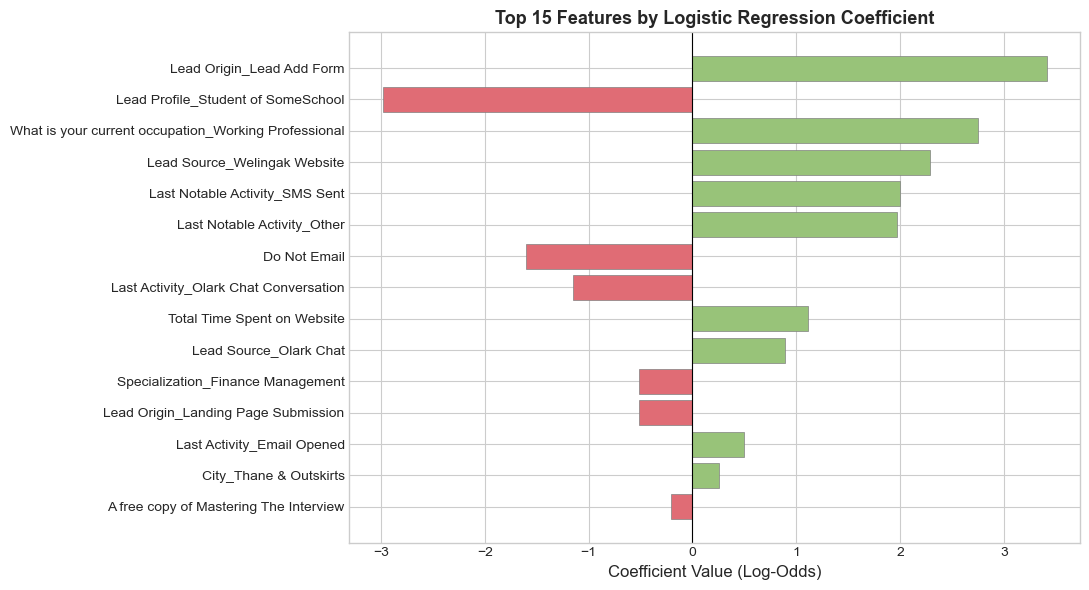

Green = increases conversion probability | Red = decreases conversion probability


In [33]:
# ── Horizontal bar chart: Top features by coefficient ────────────────────────
top_n = min(15, len(coef_df))
plot_df = coef_df.head(top_n).iloc[::-1]   # reverse for bottom-up display
colors  = ['#98C379' if v > 0 else '#E06C75' for v in plot_df['Coefficient']]

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors, edgecolor='grey', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value (Log-Odds)', fontsize=12)
plt.title(f'Top {top_n} Features by Logistic Regression Coefficient', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Green = increases conversion probability | Red = decreases conversion probability")


## Step 15: Save Results

In [34]:
# ── Export leads with scores ──────────────────────────────────────────────────
output_df = df[['Lead Score', 'Lead Category', 'Converted']].copy()
output_df.to_csv('leads_with_scores.csv', index=False)
print("Saved: leads_with_scores.csv ✓")

# Sample output
print("\nSample leads with scores (sorted by Lead Score):")
print(output_df.sort_values('Lead Score', ascending=False).head(15).to_string())


Saved: leads_with_scores.csv ✓

Sample leads with scores (sorted by Lead Score):
      Lead Score Lead Category  Converted
3478     99.9600      Hot Lead          1
2656     99.9600      Hot Lead          1
6383     99.9300      Hot Lead          1
3428     99.9300      Hot Lead          1
8074     99.9300      Hot Lead          1
7579     99.9200      Hot Lead          1
5671     99.9100      Hot Lead          1
6751     99.9100      Hot Lead          1
818      99.8900      Hot Lead          1
8081     99.8900      Hot Lead          1
7219     99.8800      Hot Lead          1
9015     99.8800      Hot Lead          1
120      99.8700      Hot Lead          1
8069     99.8500      Hot Lead          0
2786     99.8400      Hot Lead          1


In [35]:
# ── Final Model Summary ───────────────────────────────────────────────────────
print("=" * 60)
print("           FINAL MODEL SUMMARY")
print("=" * 60)
print(f"  Algorithm           : Logistic Regression")
print(f"  Features Selected   : {len(SELECTED_FEATURES)}")
print(f"  AUC-ROC (Test)      : {auc_score:.4f}")
print()
print("  At threshold = 0.50 (conservative/default):")
print(f"    Accuracy  : {accuracy_opt:.4f}")
print()
print(f"  At threshold = 0.30 (CEO target ~80% sensitivity):")
print(f"    Sensitivity : {sensitivity_opt:.4f}  ({sensitivity_opt*100:.1f}%)")
print(f"    Specificity : {specificity_opt:.4f}  ({specificity_opt*100:.1f}%)")
print(f"    Precision   : {precision_opt:.4f}")
print()
print("  Lead Score Distribution:")
print(df['Lead Category'].value_counts().to_string())
print()
print("  Business Goal: CEO targets ~80% conversion rate from predicted")
print(f"  positives → Achieved {sensitivity_opt*100:.1f}% at threshold 0.30 ✓")
print("=" * 60)


           FINAL MODEL SUMMARY
  Algorithm           : Logistic Regression
  Features Selected   : 17
  AUC-ROC (Test)      : 0.8737

  At threshold = 0.50 (conservative/default):
    Accuracy  : 0.7864

  At threshold = 0.30 (CEO target ~80% sensitivity):
    Sensitivity : 0.8380  (83.8%)
    Specificity : 0.7541  (75.4%)
    Precision   : 0.6811

  Lead Score Distribution:
Lead Category
Cold Lead    5486
Hot Lead     2151
Warm Lead    1603

  Business Goal: CEO targets ~80% conversion rate from predicted
  positives → Achieved 83.8% at threshold 0.30 ✓
